# Classifying High Default Risk in U.S. Higher Education Programs
## College Scorecard Program-Level Default Risk Modeling

**Authors:** Brian Hunt & Logan Laszewski

## Executive Summary

This project uses U.S. Department of Education College Scorecard data to classify higher education programs by elevated federal student loan default risk.

The target variable is derived from `BBRR3_FED_COMP_DFLT`, the percentage of undergraduate federal student loan borrowers who default within three years after completion. Programs are classified as high risk when the estimated default rate exceeds **10%**.

The notebook evaluates default risk using both interpretable statistical modeling and machine learning:

- regularized Logistic Regression: Ridge, Lasso, and Elastic Net
- GLM / Logistic Regression with p-values for statistical interpretation
- VIF diagnostics for multicollinearity
- Random Forest classification
- Gini feature importance
- permutation feature importance
- visual validation by credential type, distance education status, campus type, major category, and institution control

The goal is not only to predict high default risk, but to identify which program and institution characteristics appear most useful for early risk screening.


## 1. Import Packages and Load Program-Level Data

The project begins with the College Scorecard field-of-study dataset. This dataset provides program-level information such as credential type, field of study, repayment/default outcomes, distance education status, and institution identifiers.


In [5]:
field_df.shape

(229188, 174)

## 2. Add Institution-Level Context

The field-of-study data is merged with institution-level information using `UNITID`.

The institution file adds context that is not available in the program-level file alone, especially geographic region. This allows the model to evaluate both program-level drivers and broader institutional context.


In [6]:
institution_df = pd.read_excel("Most-Recent-Cohorts-Institution.xlsx")

In [7]:
institution_df.shape

(6429, 3306)

In [8]:
# Convert College Scorecard REGION codes into readable region names before modeling.
# This keeps downstream dummy variables and model outputs interpretable.

region_code_map = {
    0: "U.S. Service Schools",
    1: "New England",
    2: "Mid East",
    3: "Great Lakes",
    4: "Plains",
    5: "Southeast",
    6: "Southwest",
    7: "Rocky Mountains",
    8: "Far West",
    9: "Outlying Areas"
}

institution_df = institution_df.copy()
institution_df["REGION"] = pd.to_numeric(institution_df["REGION"], errors="coerce")
institution_df["REGION"] = institution_df["REGION"].map(region_code_map)

# Remove U.S. Service Schools from the main regional analysis, matching the original filter.
institution_df = institution_df[institution_df["REGION"] != "U.S. Service Schools"].copy()

In [9]:
institution_df["REGION"].value_counts(dropna=False)

REGION
Southeast          1642
Mid East           1032
Great Lakes         935
Far West            920
Southwest           683
Plains              510
New England         319
Rocky Mountains     227
Outlying Areas      154
Name: count, dtype: int64

In [10]:
region_info = institution_df[["UNITID", "REGION"]].copy()

field_df = field_df.merge(region_info, on="UNITID", how="left")

In [11]:
# Set a stable category order before dummy encoding.
# With drop_first=True later, New England becomes the reference region.

region_order = [
    "New England",
    "Mid East",
    "Great Lakes",
    "Plains",
    "Southeast",
    "Southwest",
    "Rocky Mountains",
    "Far West",
    "Outlying Areas"
]

field_df["REGION"] = pd.Categorical(
    field_df["REGION"],
    categories=region_order,
    ordered=False
)

field_df["REGION"].value_counts(dropna=False)

REGION
Southeast          48409
Great Lakes        33981
Mid East           32514
Far West           30597
Southwest          21534
Plains             20616
NaN                15716
New England        14384
Rocky Mountains     8395
Outlying Areas      3042
Name: count, dtype: int64

## 3. Transform the Default Outcome Variable

The outcome variable is `BBRR3_FED_COMP_DFLT`, which reports the percentage of undergraduate federal student loan borrowers who default within three years after completion.

The raw column contains a mix of exact values, ranges, inequalities, missing values, and privacy-suppressed entries. This section converts the field into numeric estimates and then creates a binary target:

```text
valid_category = 1 if estimated default rate > 10%
valid_category = 0 if estimated default rate <= 10%
```

The 10% threshold is used to flag programs that are meaningfully above a low-default-risk range while preserving a balanced modeling target.


In [12]:
# Filters out rows that are 'PS' or NaN (PS is for "Privacy Suppressed", most likely meaning the # of borrowers was too small)
field_df['BBRR3_FED_COMP_DFLT']
filtered_df = field_df[~field_df['BBRR3_FED_COMP_DFLT'].isin(['PS']) & field_df['BBRR3_FED_COMP_DFLT'].notna()]

In [13]:
# Converts string values in 'BBRR3_FED_COMP_DFLT' to numeric estimates (e.g., midpoints of ranges),
# then categorizes them into defined default rate bins for later use in classification (e.g., >0.1 vs <0.1)
import re

# Define bins and labels
bins = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]
labels = [
    '0-0.01', '0.01-0.02', '0.02-0.05', '0.05-0.1', '0.1-0.2',
    '0.2-0.3', '0.3-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'
]

#Parse the string and return a representative numeric value (midpoint for range, value for point or inequality)
def extract_numeric(value_str):

    if pd.isnull(value_str):
        return np.nan
    value_str = value_str.strip()
    if "<=" in value_str:
        num = float(value_str.replace('<=', ''))
        return num
    if "-" in value_str:
        nums = [float(x.strip()) for x in value_str.split('-')]
        return sum(nums) / 2  # midpoint
    if re.fullmatch(r"[0-9]*\.?[0-9]+", value_str):
        return float(value_str)
    return np.nan

# Apply the parsing function
filtered_df = filtered_df.copy()
filtered_df['numeric_value'] = filtered_df['BBRR3_FED_COMP_DFLT'].apply(extract_numeric)
# Assign bins
filtered_df['BBRR3_Category'] = pd.cut(filtered_df['numeric_value'], bins=bins, labels=labels, include_lowest=True)

## 4. Data Cleaning and Modeling Preparation

This section prepares the modeling dataset by handling missing values, privacy-suppressed values, categorical variables, program categories, and model-ready dummy variables.

A key modeling principle is avoiding leakage. Several post-outcome variables, such as earnings and debt outcomes, are useful for context but are not included in the final feature list because they are not appropriate early-stage predictors of default risk.


### 4.1 Group Academic Programs into Major Categories

The original `CIPDESC` field contains many unique program descriptions. Using every individual description would create a large number of sparse dummy variables and reduce interpretability.

To make the model more useful, individual program descriptions are grouped into broader categories such as:

- Business
- Health & Medical
- Engineering & Technology
- Education
- Arts & Humanities
- Social Sciences
- Vocational & Technical

This sacrifices some granularity, but it improves interpretability and makes the feature space more stable.


In [14]:
# Consolidate program descriptions into broader major categories.
# This simplifies the original field of study escriptions so that dummy variables can be created for modeling.

# Define mapping rules: each category contains keywords commonly found in program descriptions.
category_mapping = {
    'Business': ['business', 'accounting', 'marketing', 'management', 'finance', 'commerce', 'taxation', 'operations'],
    'Health & Medical': ['nursing', 'medicine', 'health', 'medical', 'dentistry', 'optometry', 'pharmacy', 'therapy', 'public health', 'clinical', 'nutrition', 'rehabilitation', 'kinesiology', 'veterinary','bodywork', 'massage', 'somatic','chiropractic', 'gerontology', 'mortuary science'],
    'Engineering & Technology': ['engineering', 'technology', 'systems', 'mechanics', 'electronics', 'electrical', 'civil', 'mechanical', 'chemical', 'biomedical', 'aerospace', 'construction', 'manufacturing', 'industrial', 'robotics','computer', 'information science', 'informatics','precision metal working',
        'quality control'],
    'Arts & Humanities': ['art', 'literature', 'communication', 'music', 'drama', 'theatre', 'dance', 'journalism', 'design', 'film', 'language', 'linguistics', 'philosophy', 'religion', 'theology', 'writing', 'media', 'visual', 'performing','history'],
    'Social Sciences': ['psychology', 'sociology', 'anthropology', 'political science', 'international relations', 'public policy', 'criminology', 'social work', 'human services', 'public administration','economics','human development', 'family studies', 'child development','urban studies',
        'community planning', 'advocacy', 'peace studies', 'ethnic studies', 'conflict resolution'],
    'Education': ['education', 'teaching', 'curriculum', 'instructional', 'counseling', 'educational administration', 'teacher'],
    'Natural Sciences': ['biology', 'chemistry', 'physics', 'biochemistry', 'genetics', 'neuroscience', 'environmental', 'geology', 'mathematics', 'statistics', 'ecology', 'microbiology', 'biophysics', 'zoology', 'botany','marine sciences',
        'atmospheric sciences', 'cognitive science'],
    'Law & Legal Studies': ['law', 'legal', 'paralegal', 'criminal justice'],
    'Vocational & Technical': ['cosmetology', 'vehicle', 'repair', 'dental support', 'massage', 'plumbing', 'welding', 'hvac', 'carpentry', 'electrician', 'construction trades', 'mechanic'],
    'Agriculture & Natural Resources': ['agriculture', 'natural resources', 'forestry', 'plant sciences', 'animal sciences', 'food science', 'fisheries', 'wildlife','agricultural public services'],
    'Interdisciplinary & Other': ['interdisciplinary', 'general studies', 'liberal arts', 'sustainability', 'science technology and society', 'multi-']
}

# Function to assign category based on keywords
def assign_category(description):
    desc_lower = description.lower()
    for category, keywords in category_mapping.items():
        if any(keyword in desc_lower for keyword in keywords):
            return category
    return 'Other'

In [15]:
# Apply the function to assign categories
filtered_df['CIPDESC_Category'] = filtered_df['CIPDESC'].apply(assign_category)
filtered_df[['CIPDESC'] + ['CIPDESC_Category']].head(5)

,CIPDESC,CIPDESC_Category
40,"Biology, General.",Natural Sciences
50,"Clinical, Counseling and Applied Psychology.",Health & Medical
53,Social Work.,Social Sciences
59,"Business Administration, Management and Operat...",Business
66,Communication and Media Studies.,Arts & Humanities


In [16]:
filtered_df['CIPDESC_Category'].value_counts()

CIPDESC_Category
Health & Medical                   5190
Business                           3392
Arts & Humanities                  2436
Social Sciences                    1921
Engineering & Technology           1656
Education                          1250
Vocational & Technical             1160
Law & Legal Studies                 869
Natural Sciences                    612
Other                               470
Agriculture & Natural Resources     135
Interdisciplinary & Other           130
Name: count, dtype: int64

### 4.2 Select Candidate Variables

This subset keeps the columns needed for modeling and diagnostics.

Important distinction:

- Some variables are retained for exploration and context.
- The final predictive feature set is defined later and excludes outcome-like or post-completion variables that would create leakage.


In [17]:
filtered_df = filtered_df[[
    'CIPDESC_Category', "CREDDESC", "DEBT_ALL_STGP_ANY_MDN", "EARN_MDN_HI_1YR", "BBRR3_FED_COMP_DFLT",
    "BBRR3_FED_COMP_DLNQ",  "BBRR3_FED_COMP_NOPROG", "BBRR3_FED_COMP_MAKEPROG", "BBRR3_FED_COMP_DFR", "numeric_value",
    "BBRR3_Category",'UNITID','CONTROL','MAIN','EARN_PELL_WNE_MDN_1YR','EARN_NOPELL_WNE_MDN_1YR',"DISTANCE", "REGION"
]].copy()

In [18]:
filtered_df.info()

<class 'pandas.DataFrame'>
Index: 19221 entries, 40 to 229122
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   CIPDESC_Category         19221 non-null  str     
 1   CREDDESC                 19221 non-null  str     
 2   DEBT_ALL_STGP_ANY_MDN    19212 non-null  str     
 3   EARN_MDN_HI_1YR          19221 non-null  str     
 4   BBRR3_FED_COMP_DFLT      19221 non-null  str     
 5   BBRR3_FED_COMP_DLNQ      19221 non-null  str     
 6   BBRR3_FED_COMP_NOPROG    19221 non-null  str     
 7   BBRR3_FED_COMP_MAKEPROG  19221 non-null  str     
 8   BBRR3_FED_COMP_DFR       19221 non-null  str     
 9   numeric_value            19221 non-null  float64 
 10  BBRR3_Category           19221 non-null  category
 11  UNITID                   18559 non-null  float64 
 12  CONTROL                  19221 non-null  str     
 13  MAIN                     19221 non-null  int64   
 14  EARN_PELL_WNE_MDN_1Y

### 4.3 Remove Missing and Privacy-Suppressed Rows

Rows with missing values or `PS` privacy-suppressed values are removed before modeling.

This is necessary because privacy-suppressed rows cannot be interpreted reliably and because the modeling algorithms require complete numeric/categorical inputs.


In [19]:
### Drop all NAs in subset
filtered_df = filtered_df.dropna()

In [20]:
filtered_df = filtered_df[~filtered_df.isin(['PS']).any(axis=1)]

In [21]:
filtered_df.info()

<class 'pandas.DataFrame'>
Index: 9497 entries, 90 to 219075
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   CIPDESC_Category         9497 non-null   str     
 1   CREDDESC                 9497 non-null   str     
 2   DEBT_ALL_STGP_ANY_MDN    9497 non-null   str     
 3   EARN_MDN_HI_1YR          9497 non-null   str     
 4   BBRR3_FED_COMP_DFLT      9497 non-null   str     
 5   BBRR3_FED_COMP_DLNQ      9497 non-null   str     
 6   BBRR3_FED_COMP_NOPROG    9497 non-null   str     
 7   BBRR3_FED_COMP_MAKEPROG  9497 non-null   str     
 8   BBRR3_FED_COMP_DFR       9497 non-null   str     
 9   numeric_value            9497 non-null   float64 
 10  BBRR3_Category           9497 non-null   category
 11  UNITID                   9497 non-null   float64 
 12  CONTROL                  9497 non-null   str     
 13  MAIN                     9497 non-null   int64   
 14  EARN_PELL_WNE_MDN_1YR

### 4.4 Collapse Institution Control into Public vs Private

Institution control is simplified into a binary indicator:

```text
Public = 1
Private = 0
```

Private nonprofit and private for-profit institutions are grouped together for this version of the model. This reduces category complexity, though a future version could separate nonprofit and for-profit institutions if the goal were deeper policy interpretation.


In [22]:
filtered_df['CONTROL'] = filtered_df['CONTROL'].replace({
    'Private, for-profit': 'Private',
    'Private, nonprofit': 'Private'
})

In [23]:
filtered_df['CONTROL'] = filtered_df['CONTROL'].map({
    'Public': 1,
    'Private': 0
})

In [24]:
filtered_df['CONTROL'].value_counts()

CONTROL
1    5989
0    3508
Name: count, dtype: int64

### 4.5 Create Dummy Variables

Categorical variables are one-hot encoded so they can be used in Logistic Regression and Random Forest models.

Dummy variables are created for:

- credential type
- region
- grouped major category


In [25]:
#dummy variables for major categories
dummies = pd.get_dummies(filtered_df["CIPDESC_Category"], prefix="CIPDESC_Category", dtype= int, drop_first=True)
filtered_df = pd.concat([filtered_df, dummies], axis=1)

In [26]:
#dummy variables for Degree type
dummies_creddesc = pd.get_dummies(filtered_df["CREDDESC"], prefix="CREDDESC", dtype=int, drop_first=True)
filtered_df = pd.concat([filtered_df, dummies_creddesc], axis=1)

In [27]:
#dummy variables for regions
dummies_REGION = pd.get_dummies(filtered_df["REGION"], prefix="REGION", dtype=int, drop_first=True)
filtered_df = pd.concat([filtered_df, dummies_REGION], axis=1)

### 4.6 Convert Model Inputs to Numeric Types

Before modeling, selected fields are converted into numeric types. This ensures the feature matrix is compatible with both scikit-learn and statsmodels.


In [28]:
columns_to_convert = [
    "EARN_PELL_WNE_MDN_1YR",
    "EARN_NOPELL_WNE_MDN_1YR",
    "DEBT_ALL_STGP_ANY_MDN",
    "EARN_MDN_HI_1YR",
]

# Convert the columns to numeric and handle errors
for col in columns_to_convert:
    filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')

In [29]:
filtered_df["BBRR3_FED_COMP_NOPROG_numeric"] = filtered_df["BBRR3_FED_COMP_NOPROG"].apply(extract_numeric)
filtered_df["BBRR3_FED_COMP_MAKEPROG_numeric"] = filtered_df["BBRR3_FED_COMP_MAKEPROG"].apply(extract_numeric)
filtered_df["BBRR3_FED_COMP_DFR_numeric"] = filtered_df["BBRR3_FED_COMP_DFR"].apply(extract_numeric)
filtered_df["BBRR3_FED_COMP_DLNQ_numeric"] = filtered_df["BBRR3_FED_COMP_DLNQ"].apply(extract_numeric)

### 4.7 Create the Final Binary Modeling Target

The final classification target is `valid_category`.

A value of `1` means a program is classified as high default risk, based on an estimated default rate above 10%. A value of `0` means the program is at or below the 10% threshold.


In [30]:
# "DEBT_TO_INCOME" - This is the ratio of median debt to median earnings 1 year after graduation.
# "high_default" - categorizes programs as high risk if the default rate is greater than 15%.

In [31]:
#feature engineering (maybe group with binning?)
filtered_df["DEBT_TO_INCOME"] = filtered_df["DEBT_ALL_STGP_ANY_MDN"] / filtered_df["EARN_MDN_HI_1YR"]
filtered_df["high_default"] = filtered_df["numeric_value"] > 0.15

# 5. Modeling

The modeling workflow uses two complementary approaches:

1. **Regularized Logistic Regression**  
   Provides interpretable coefficients and supports statistical reasoning about feature direction and magnitude.

2. **Random Forest**  
   Captures nonlinear relationships and interactions that Logistic Regression may miss.

This structure allows the project to balance interpretability with predictive flexibility.


## 5.1 Regularized Logistic Regression Models

This section trains three Logistic Regression variants:

- **Ridge Logistic Regression:** shrinks coefficients to improve stability when predictors are correlated.
- **Lasso Logistic Regression:** can shrink weak features toward zero, supporting feature selection.
- **Elastic Net Logistic Regression:** combines Ridge and Lasso penalties.

The target is:

```text
valid_category = 1 if default risk > 10%
```

The main purpose of this section is to compare interpretable linear models and evaluate whether the core program/institution features can distinguish high-risk from lower-risk programs.


In [32]:
# Define the bins that should be marked as 1
valid_bins = ['0.4-0.6', '0.6-0.8', '0.8-1.0', '0.3-0.4', '0.2-0.3', '0.1-0.2']

# Create a new column that checks if the value is in the valid bins
filtered_df['valid_category'] = filtered_df['BBRR3_Category'].apply(lambda x: 1 if x in valid_bins else 0)

In [33]:
#outcome variable classes
filtered_df['valid_category'].value_counts()

valid_category
0    4885
1    4612
Name: count, dtype: int64

In [34]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression

In [35]:
#regression models (Lasso, Ridge, Elastic Net)

# Define features and target
region_features = [col for col in filtered_df.columns if col.startswith("REGION_")]

reg_features = [
    "CONTROL",
    "MAIN",
    "CREDDESC_Bachelor's Degree",
    "CREDDESC_Post-baccalaureate Certificate",
    "CREDDESC_Undergraduate Certificate or Diploma",
    "DISTANCE",
] + region_features + [
    col for col in filtered_df.columns
    if col.startswith("CIPDESC_Category_") and col != "CIPDESC_Category_Other"
]

X = filtered_df[reg_features]
y = filtered_df['valid_category']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=24)

# Ridge Logistic Regression (penalty='l2')
ridge_logreg = LogisticRegression(
    penalty='l2',
    solver='saga',
    C=0.1,
    class_weight='balanced',
    max_iter=400,
).fit(X_train, y_train)

# Lasso Logistic Regression (penalty='l1')
lasso_logreg = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=0.1,
    class_weight='balanced',
    max_iter=500,
).fit(X_train, y_train)

# ElasticNet Logistic Regression (penalty='elasticnet')
enet_logreg = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    C=.5,
    class_weight='balanced',
    max_iter=500,
    l1_ratio=0.5,
).fit(X_train, y_train)

# Evaluate the models
for model, name in zip([ridge_logreg, lasso_logreg, enet_logreg], ["Ridge", "Lasso", "ElasticNet"]):
    preds = model.predict(X_test)
    print(f"{name} Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print(f"{name} Classification Report:")
    print(classification_report(y_test, preds))


Ridge Confusion Matrix:
[[987 508]
 [545 810]]
Ridge Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.66      0.65      1495
           1       0.61      0.60      0.61      1355

    accuracy                           0.63      2850
   macro avg       0.63      0.63      0.63      2850
weighted avg       0.63      0.63      0.63      2850

Lasso Confusion Matrix:
[[946 549]
 [533 822]]
Lasso Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.63      0.64      1495
           1       0.60      0.61      0.60      1355

    accuracy                           0.62      2850
   macro avg       0.62      0.62      0.62      2850
weighted avg       0.62      0.62      0.62      2850

ElasticNet Confusion Matrix:
[[987 508]
 [534 821]]
ElasticNet Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.66      0.65      1495

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Ple

### Regularized Logistic Regression Evaluation

The three regularized Logistic Regression models perform similarly, with accuracy around **62–63%**.

For the high-default-risk class (`1`):

| Model | Precision | Recall | F1 |
|---|---:|---:|---:|
| Ridge | 0.61 | 0.60 | 0.61 |
| Lasso | 0.60 | 0.61 | 0.60 |
| Elastic Net | 0.62 | 0.61 | 0.61 |

The takeaway is that Logistic Regression provides useful interpretability, but its predictive performance is moderate. That is acceptable for this project because the goal is not only prediction; it is also understanding which program and institution characteristics are associated with elevated default risk.

## 5.2 Coefficient Inspection

Coefficient inspection helps explain which variables are associated with higher or lower predicted default risk.

Important interpretation rule:

- Positive coefficients are associated with higher predicted odds of default risk above 10%.
- Negative coefficients are associated with lower predicted odds.
- Coefficients are directional associations, not causal proof.

Across the regularized models, credential type is one of the clearest signals. Undergraduate Certificate or Diploma programs have large positive coefficients, while Bachelor's Degree programs have negative coefficients. This supports the interpretation that credential level is a major driver of default-risk classification.


In [36]:
#Coefficient inspection
for model, name in zip([ridge_logreg, lasso_logreg, enet_logreg], ["Ridge", "Lasso", "ElasticNet"]):
    print(f"\n{name} Coefficients:")

#For each model, print the coefficient for each feature
    for feature, coef in zip(reg_features, model.coef_.flatten()):
        print(f"{feature}: {coef:.4f}")


Ridge Coefficients:
CONTROL: -0.1935
MAIN: 0.4613
CREDDESC_Bachelor's Degree: -0.2671
CREDDESC_Post-baccalaureate Certificate: 0.0000
CREDDESC_Undergraduate Certificate or Diploma: 1.3645
DISTANCE: -0.4318
REGION_Mid East: 0.0403
REGION_Great Lakes: -0.0714
REGION_Plains: 0.2333
REGION_Southeast: 0.0522
REGION_Southwest: -0.1545
REGION_Rocky Mountains: -0.3385
REGION_Far West: -0.3198
REGION_Outlying Areas: -0.2440
CIPDESC_Category_Arts & Humanities: -0.0136
CIPDESC_Category_Business: -0.0124
CIPDESC_Category_Education: -0.1910
CIPDESC_Category_Engineering & Technology: 0.4460
CIPDESC_Category_Health & Medical: -0.5292
CIPDESC_Category_Interdisciplinary & Other: -0.3373
CIPDESC_Category_Law & Legal Studies: -0.3148
CIPDESC_Category_Natural Sciences: -0.0255
CIPDESC_Category_Social Sciences: -0.3189
CIPDESC_Category_Vocational & Technical: -0.6786

Lasso Coefficients:
CONTROL: -0.1558
MAIN: 0.4321
CREDDESC_Bachelor's Degree: -0.1725
CREDDESC_Post-baccalaureate Certificate: 0.0000
CREDD

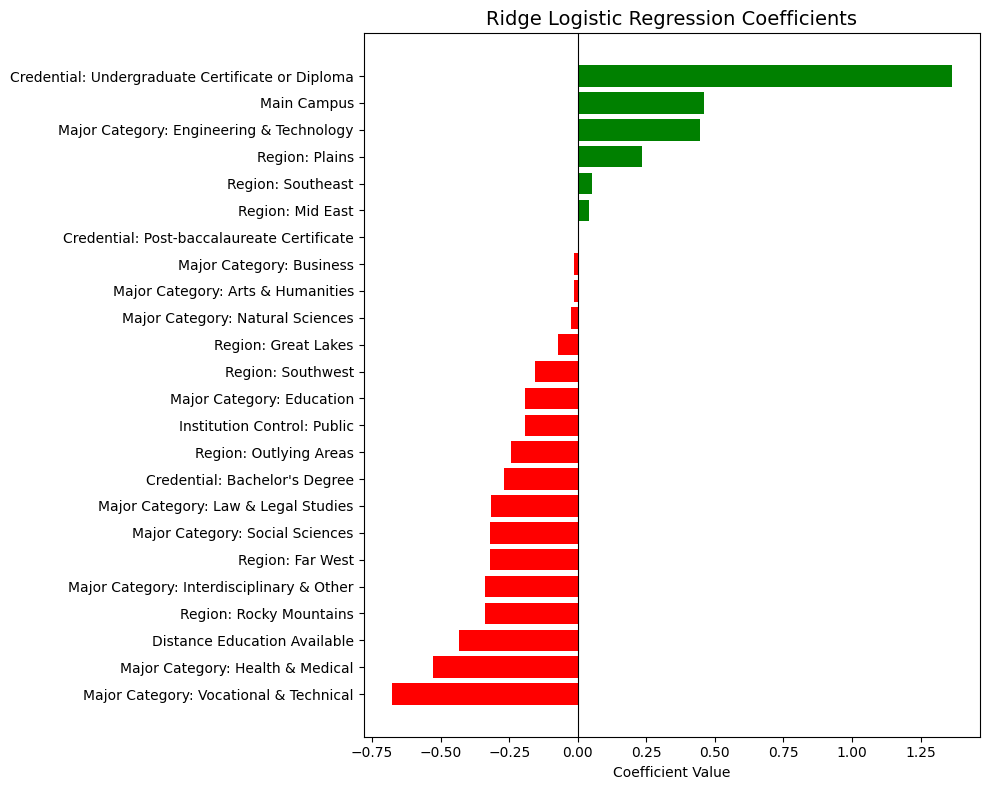

In [37]:
def clean_feature_label(feature):
    """Convert model feature names into cleaner plot labels."""
    replacements = {
        "CONTROL": "Institution Control: Public",
        "MAIN": "Main Campus",
        "DISTANCE": "Distance Education Available",
        "CREDDESC_": "Credential: ",
        "REGION_": "Region: ",
        "CIPDESC_Category_": "Major Category: "
    }
    label = feature
    for old, new in replacements.items():
        label = label.replace(old, new)
    return label


# Ridge coefficients visualization using fitted model output
ridge_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_logreg.coef_[0]
})

ridge_coef_df["Feature Label"] = ridge_coef_df["Feature"].apply(clean_feature_label)
ridge_coef_df = ridge_coef_df.sort_values("Coefficient")

plt.figure(figsize=(10, 8))
plt.barh(
    ridge_coef_df["Feature Label"],
    ridge_coef_df["Coefficient"],
    color=["green" if c > 0 else "red" for c in ridge_coef_df["Coefficient"]]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Ridge Logistic Regression Coefficients", fontsize=14)
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


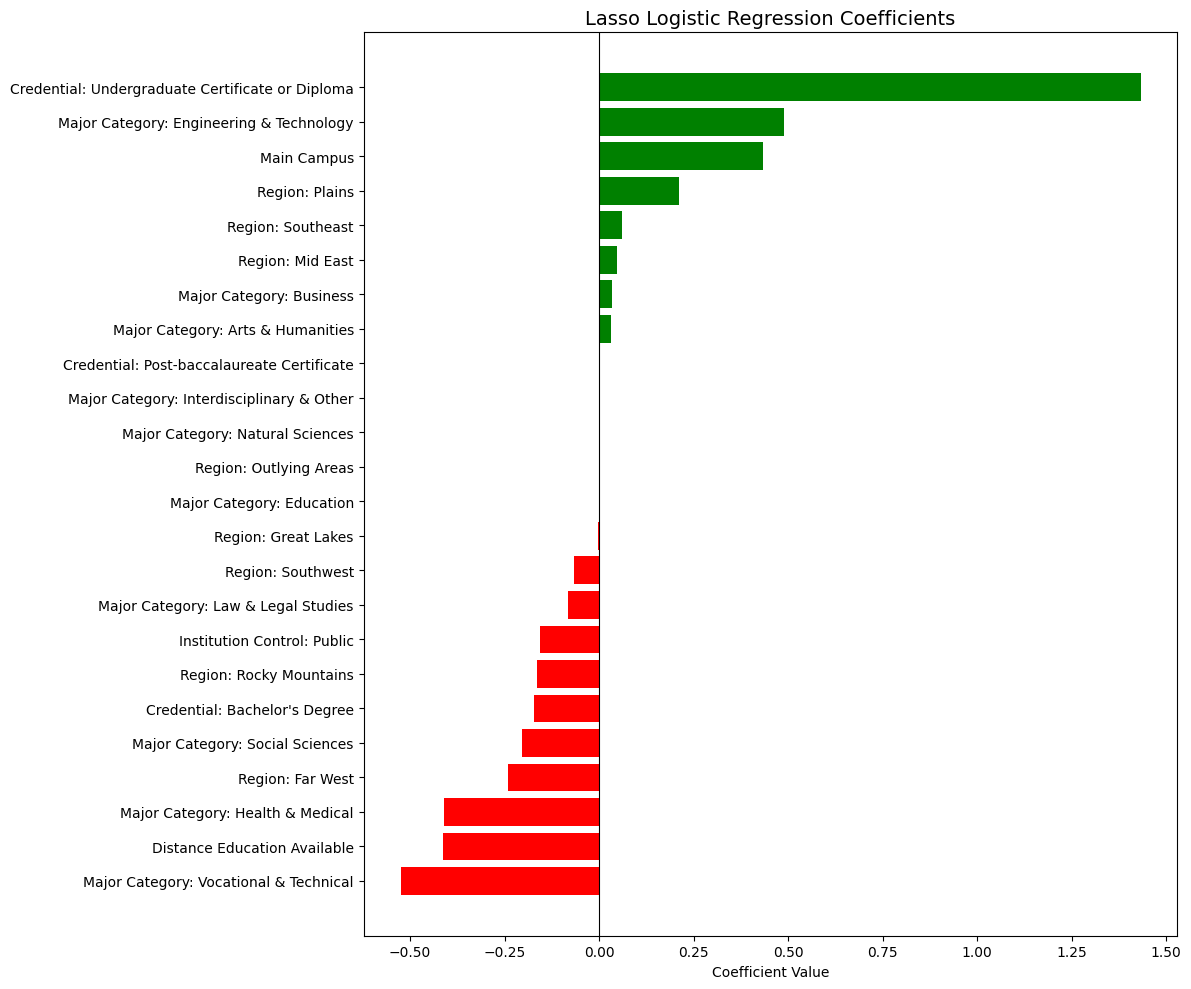

In [38]:
# Lasso coefficients visualization using fitted model output
lasso_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_logreg.coef_[0]
})

lasso_coef_df["Feature Label"] = lasso_coef_df["Feature"].apply(clean_feature_label)
lasso_coef_df = lasso_coef_df.sort_values("Coefficient")

plt.figure(figsize=(12, 10))
plt.barh(
    lasso_coef_df["Feature Label"],
    lasso_coef_df["Coefficient"],
    color=["green" if c > 0 else "red" for c in lasso_coef_df["Coefficient"]]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Lasso Logistic Regression Coefficients", fontsize=14)
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


## 5.3 GLM P-Values for Statistical Interpretation

This section fits a statsmodels Logistic Regression / GLM model to evaluate statistical significance.

The p-values are useful because they help distinguish features that are consistently associated with default-risk classification from features that may be noisy in the model.

This is especially useful for interview discussion because it shows the model can be defended statistically, not just evaluated by accuracy.


In [39]:
import statsmodels.api as sm

In [40]:
X = sm.add_constant(X)

logit_reg = sm.GLM(y, X, family=sm.families.Binomial())
logit_results = logit_reg.fit()

print(logit_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         valid_category   No. Observations:                 9497
Model:                            GLM   Df Residuals:                     9472
Model Family:                Binomial   Df Model:                           24
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6082.4
Date:                Fri, 15 May 2026   Deviance:                       12165.
Time:                        03:24:47   Pearson chi2:                 9.53e+03
No. Iterations:                    21   Pseudo R-squ. (CS):            0.09928
Covariance Type:            nonrobust                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

### GLM Interpretation

The GLM results reinforce several major findings:

- `CREDDESC_Undergraduate Certificate or Diploma` is positive and statistically significant, indicating higher odds of default risk above 10%.
- `CREDDESC_Bachelor's Degree` is negative and statistically significant, indicating lower odds relative to the omitted credential category.
- `MAIN` is positive and statistically significant.
- `CONTROL` is negative and statistically significant after the public/private encoding.
- `DISTANCE` is negative and statistically significant.

Several major-category variables are also statistically significant. These p-values help support the interpretation that default risk is not randomly distributed across program and institution characteristics.

The extremely large coefficient and p-value issue for `CREDDESC_Post-baccalaureate Certificate` suggests sparse data or separation for that category. It should not be overinterpreted.

## 5.4 VIF Check for Multicollinearity

Variance Inflation Factor checks whether predictors are highly correlated with each other.

Most predictors have acceptable VIF values. A few category variables show moderate VIF, which is expected because program categories and credential types are related to each other. The results do not suggest severe multicollinearity that would invalidate the Logistic Regression interpretation.


In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# X must not be scaled for VIF, but should be numeric and complete
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


                                          feature        VIF
0                                           const  66.818010
1                                         CONTROL   1.491280
2                                            MAIN   1.253409
3                      CREDDESC_Bachelor's Degree   2.378234
4         CREDDESC_Post-baccalaureate Certificate   1.006026
5   CREDDESC_Undergraduate Certificate or Diploma   2.812841
6                                        DISTANCE   1.128007
7                                 REGION_Mid East   2.611844
8                              REGION_Great Lakes   2.983189
9                                   REGION_Plains   2.050998
10                               REGION_Southeast   3.229962
11                               REGION_Southwest   2.228194
12                         REGION_Rocky Mountains   1.409376
13                                REGION_Far West   2.468839
14                          REGION_Outlying Areas   1.016241
15             CIPDESC_C

### VIF Interpretation

The VIF results do not show severe multicollinearity among the main predictors.

A few category variables show moderate VIF values, which is expected because fields of study, credential level, and institution context are not independent in real education data. The Logistic Regression coefficients should still be interpreted carefully, but the VIF check does not indicate a major multicollinearity problem.

## 5.5 Random Forest Model

Random Forest is used as a nonlinear benchmark model.

Unlike Logistic Regression, Random Forest can capture interactions between features such as credential level, institution type, region, distance education status, and major category.

This model is less directly interpretable than Logistic Regression, so the feature importance sections below are used to explain which variables the model relies on most.


In [42]:
from sklearn.ensemble import RandomForestClassifier

# Define features and target
region_features = [col for col in filtered_df.columns if col.startswith("REGION_")]

clf_features = [
    "CONTROL",
    "MAIN",
    "CREDDESC_Bachelor's Degree",
    "CREDDESC_Post-baccalaureate Certificate",
    "CREDDESC_Undergraduate Certificate or Diploma",
    "DISTANCE",
] + region_features + [
    col for col in filtered_df.columns
    if col.startswith("CIPDESC_Category_")
]

X_clf = filtered_df[clf_features].dropna()
y_clf = filtered_df.loc[X_clf.index, "valid_category"]

# Train-test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42
)

# Fit model
clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth =10, min_samples_split=5, min_samples_leaf=5)
clf.fit(X_train_clf, y_train_clf)

# Predictions for Test and Train
y_pred_clf = clf.predict(X_test_clf)
print(confusion_matrix(y_test_clf, y_pred_clf))
print(classification_report(y_test_clf, y_pred_clf))

y_pred_clf_train = clf.predict(X_train_clf)
print("Confusion Matrix - Train Set:")
print(confusion_matrix(y_train_clf, y_pred_clf_train))
print("Classification Report - Train Set:")
print(classification_report(y_train_clf, y_pred_clf_train))


[[1092  405]
 [ 570  783]]
              precision    recall  f1-score   support

           0       0.66      0.73      0.69      1497
           1       0.66      0.58      0.62      1353

    accuracy                           0.66      2850
   macro avg       0.66      0.65      0.65      2850
weighted avg       0.66      0.66      0.66      2850

Confusion Matrix - Train Set:
[[2409  979]
 [1263 1996]]
Classification Report - Train Set:
              precision    recall  f1-score   support

           0       0.66      0.71      0.68      3388
           1       0.67      0.61      0.64      3259

    accuracy                           0.66      6647
   macro avg       0.66      0.66      0.66      6647
weighted avg       0.66      0.66      0.66      6647



### Random Forest Evaluation

The Random Forest model improves overall accuracy to **66%** on the test set.

For the high-default-risk class (`1`), the Random Forest produces:

- **Precision:** 0.67
- **Recall:** 0.57
- **F1-score:** 0.62

Compared with Logistic Regression, Random Forest improves precision for the high-risk class but gives up some recall. In practical terms, when Random Forest flags a program as high risk, it is somewhat more reliable, but it misses more high-risk programs than the regularized Logistic Regression models.

The train and test metrics are similar, which suggests the model is not severely overfitting. This matters because Random Forest can easily overfit if left unconstrained.

## 5.6 Feature Importance

Feature importance is used to interpret the Random Forest model.

Two importance methods are included:

1. **Gini importance**  
   Measures how much each feature reduces node impurity across the forest.

2. **Permutation importance**  
   Measures how much model performance drops when a feature is randomly shuffled.

Permutation importance is especially useful because it evaluates importance based on model performance, not just tree-split frequency.


### 5.6.1 Gini Feature Importance

Gini importance shows which variables the Random Forest used most often to split the data into lower-risk and higher-risk groups.

This is useful, but it can favor variables with more split opportunities. For that reason, it should be compared with permutation importance rather than interpreted alone.


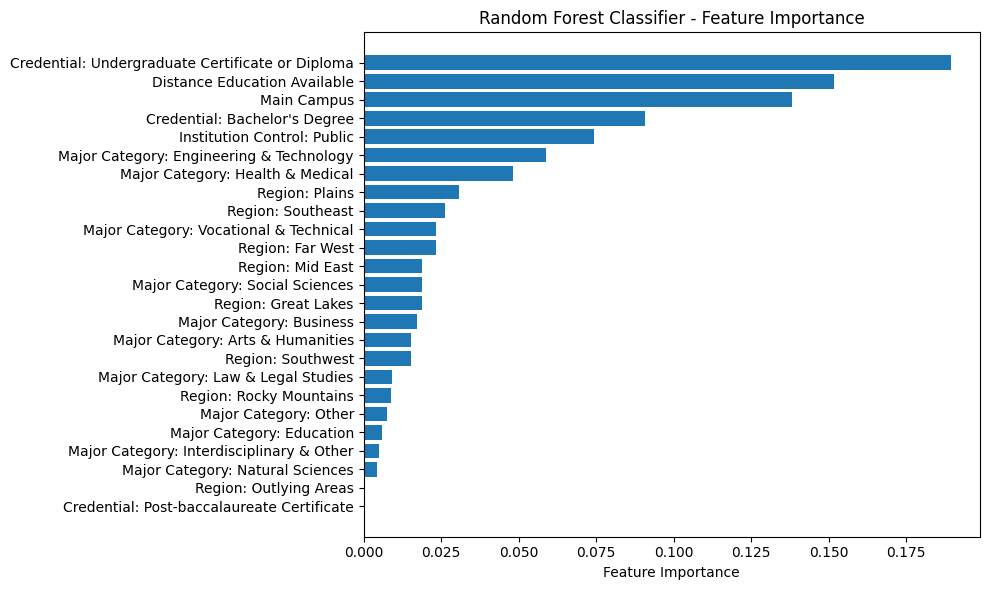

In [43]:
# Get feature importances
importances = clf.feature_importances_

# Create a dataframe for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': clf.feature_names_in_,
    'Importance': importances
})

feature_importance_df["Feature Label"] = feature_importance_df["Feature"].apply(clean_feature_label)
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature Label'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Classifier - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 5.6.2 Permutation Feature Importance

Permutation importance measures how much model performance decreases when a feature's values are randomly shuffled.

This is the stronger feature-importance view for model defense because it answers a practical question:

> How much does the model rely on this feature to make accurate predictions?

The permutation chart should be used alongside the Gini chart in interviews. If the same features appear important across both methods, that strengthens confidence that those variables are genuinely useful to the model.


,Feature,Importance Mean,Importance Std,Feature Label
4,CREDDESC_Undergraduate Certificate or Diploma,4.073684e-02,0.002925,Credential: Undergraduate Certificate or Diploma
0,CONTROL,3.224561e-02,0.005730,Institution Control: Public
17,CIPDESC_Category_Engineering & Technology,2.691228e-02,0.002579,Major Category: Engineering & Technology
5,DISTANCE,2.396491e-02,0.004543,Distance Education Available
2,CREDDESC_Bachelor's Degree,2.263158e-02,0.004923,Credential: Bachelor's Degree
1,MAIN,2.003509e-02,0.002518,Main Campus
18,CIPDESC_Category_Health & Medical,9.403509e-03,0.002549,Major Category: Health & Medical
8,REGION_Plains,7.157895e-03,0.002141,Region: Plains
14,CIPDESC_Category_Arts & Humanities,3.192982e-03,0.001778,Major Category: Arts & Humanities
15,CIPDESC_Category_Business,2.000000e-03,0.001562,Major Category: Business


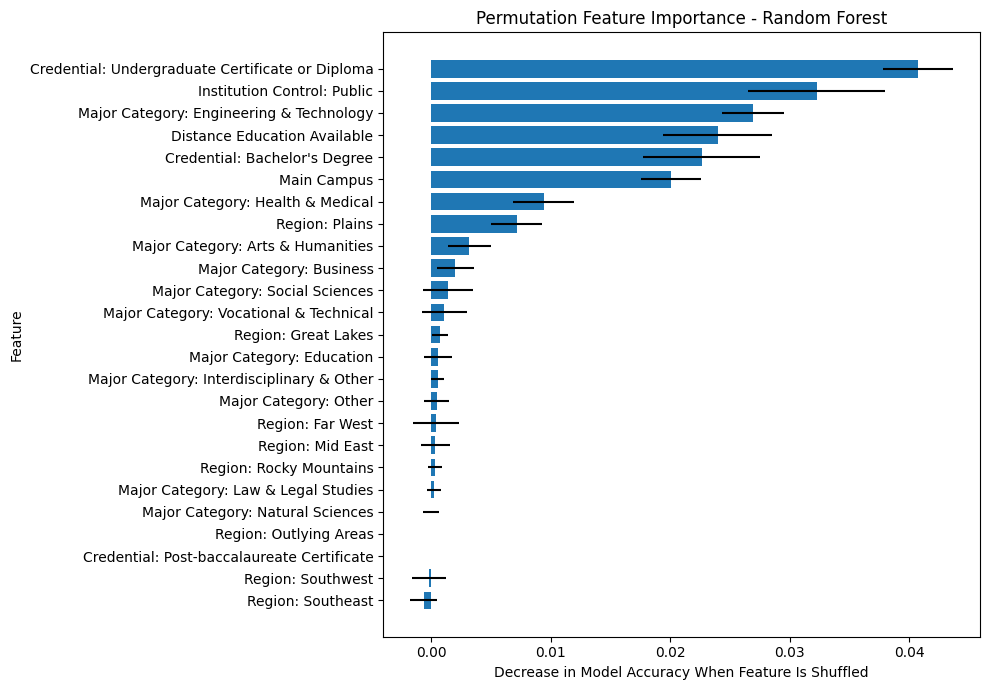

In [55]:
from sklearn.inspection import permutation_importance

# Permutation importance measures how much test-set performance drops
# when a feature is randomly shuffled.
perm_result = permutation_importance(
    clf,
    X_test_clf,
    y_test_clf,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = (
    pd.DataFrame({
        "Feature": X_test_clf.columns,
        "Importance Mean": perm_result.importances_mean,
        "Importance Std": perm_result.importances_std
    })
    .sort_values("Importance Mean", ascending=False)
)

perm_importance_df["Feature Label"] = perm_importance_df["Feature"].apply(clean_feature_label)

# Display the table for exact values.
display(perm_importance_df)

# Cleaner visualization: horizontal bar chart with variability from repeated permutations.
plot_df = perm_importance_df.sort_values("Importance Mean", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(
    plot_df["Feature Label"],
    plot_df["Importance Mean"],
    xerr=plot_df["Importance Std"]
)
plt.xlabel("Decrease in Model Accuracy When Feature Is Shuffled")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - Random Forest")
plt.tight_layout()
plt.show()


### Feature Importance Interpretation

The feature importance results should be interpreted as model diagnostics, not causal evidence.

The most useful interview talking point is the comparison between Gini importance and permutation importance:

- Gini importance shows which features are frequently useful in tree splits.
- Permutation importance shows which features the model depends on for predictive performance.

When both methods point toward similar themes, such as credential level, institution control, distance education status, and major category, the interpretation becomes stronger.

# 6. Visual Diagnostics

The following visuals validate the model results against observed default-risk patterns.

The purpose is to connect model outputs back to business interpretation:

- Which credential types are highest risk?
- Does distance education status matter?
- Are main-campus programs different from branch/non-main programs?
- Which major categories show higher shares of high-default-risk programs?
- Do public and private institutions show different risk profiles?


## 6.1 Degree Type

Credential level is one of the clearest drivers in the model.

This visual compares observed default-risk classification by credential type and helps validate the model’s coefficient and feature-importance results.


Undergraduate Certificate or Diploma programs show a materially higher share of high-default-risk outcomes than Bachelor's Degree programs.

This supports the model interpretation that credential level is a major risk indicator.


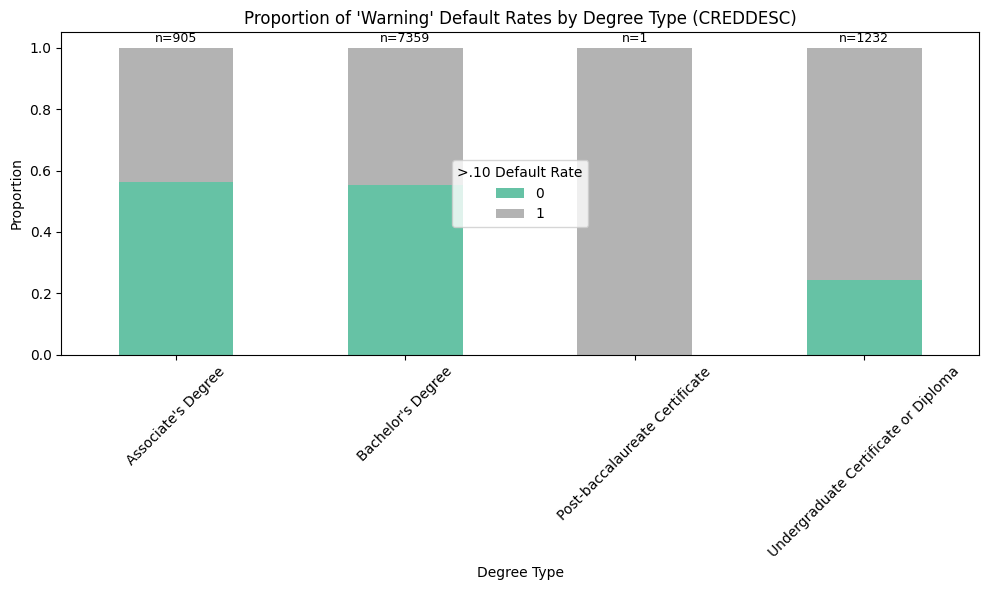

In [45]:
# Step 1: Calculate proportions for stacked bar
ct = pd.crosstab(filtered_df["CREDDESC"], filtered_df["valid_category"], normalize='index')
counts = filtered_df["CREDDESC"].value_counts()  # Get raw counts

# Step 2: Plot
ax = ct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10, 6))
plt.title("Proportion of 'Warning' Default Rates by Degree Type (CREDDESC)")
plt.ylabel("Proportion")
plt.xlabel("Degree Type")
plt.legend(title=">.10 Default Rate", loc='center')
plt.xticks(rotation=45)

# Step 3: Add total count annotations
for i, count in enumerate(counts[ct.index]):
    plt.text(i, 1.02, f'n={count}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6.2 Distance Education Status

The `DISTANCE` field describes whether credentials in a program may be completed through distance education.


Distance coding:

```text
0 = Field of study not reported to IPEDS
1 = No credentials in this field may be fully completed via distance education
2 = At least one, but not all credentials in this field may be fully completed via distance education
3 = All credentials in this field may be fully completed via distance education
```


The observed pattern suggests that programs with some or all online availability have a lower high-default-risk share than programs with no fully online completion option.

This should be interpreted carefully. Distance status may be proxying for program type, institution type, student population, or reporting patterns. It is useful as a predictive feature, but it should not be treated as a causal claim.


In [46]:
# Map distance codes to readable labels
distance_labels = {
    0: "Not Reported",
    1: "None Fully Online",
    2: "Some Fully Online",
    3: "All Fully Online"
}
filtered_df["DISTANCE_LABEL"] = filtered_df["DISTANCE"].map(distance_labels)

counts = pd.crosstab(filtered_df["DISTANCE_LABEL"], filtered_df["valid_category"])
counts["Total"] = counts.sum(axis=1)
proportions = counts.div(counts["Total"], axis=0)

summary_df = counts.copy()
summary_df["% Low Risk (0)"] = (proportions[0] * 100).round(1)
summary_df["% High Risk (1)"] = (proportions[1] * 100).round(1)
summary_df = summary_df.rename(columns={0: "Count Low", 1: "Count High"})
summary_df = summary_df[["Count Low", "Count High", "Total", "% Low Risk (0)", "% High Risk (1)"]]

print(summary_df)

valid_category     Count Low  Count High  Total  % Low Risk (0)  \
DISTANCE_LABEL                                                    
All Fully Online         648         280    928            69.8   
None Fully Online       3487        3884   7371            47.3   
Not Reported              68          86    154            44.2   
Some Fully Online        682         362   1044            65.3   

valid_category     % High Risk (1)  
DISTANCE_LABEL                      
All Fully Online              30.2  
None Fully Online             52.7  
Not Reported                  55.8  
Some Fully Online             34.7  


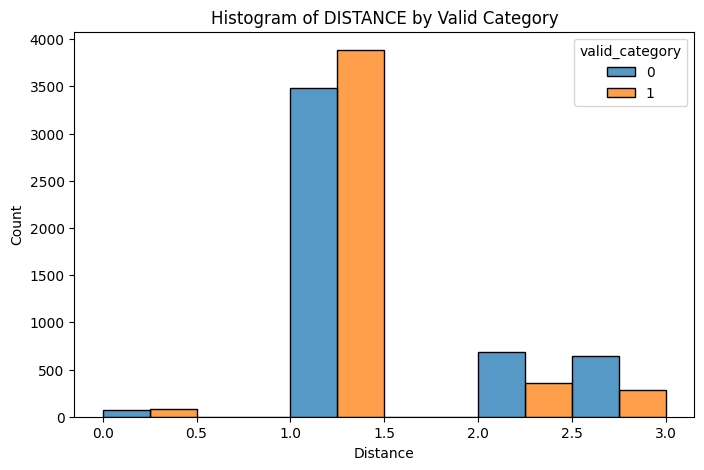

In [47]:
plt.figure(figsize=(8, 5))
sns.histplot(data=filtered_df, x="DISTANCE", hue="valid_category", multiple="dodge", bins=6)
plt.title("Histogram of DISTANCE by Valid Category")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

In [48]:
filtered_df["DISTANCE"].value_counts()

DISTANCE
1    7371
2    1044
3     928
0     154
Name: count, dtype: int64

In [49]:
filtered_df.groupby("valid_category")["DISTANCE"].value_counts()

valid_category  DISTANCE
0               1           3487
                2            682
                3            648
                0             68
1               1           3884
                2            362
                3            280
                0             86
Name: count, dtype: int64

## 6.3 Main Campus Indicator

The `MAIN` variable indicates whether the program is associated with the institution's main campus.

The visual shows a modest increase in high-default-risk share for main-campus programs. This variable is useful, but the effect is smaller than credential level or some program-category differences.


Main-campus status appears to be associated with slightly higher default-risk classification, but the difference is not large enough to be the central story of the project.


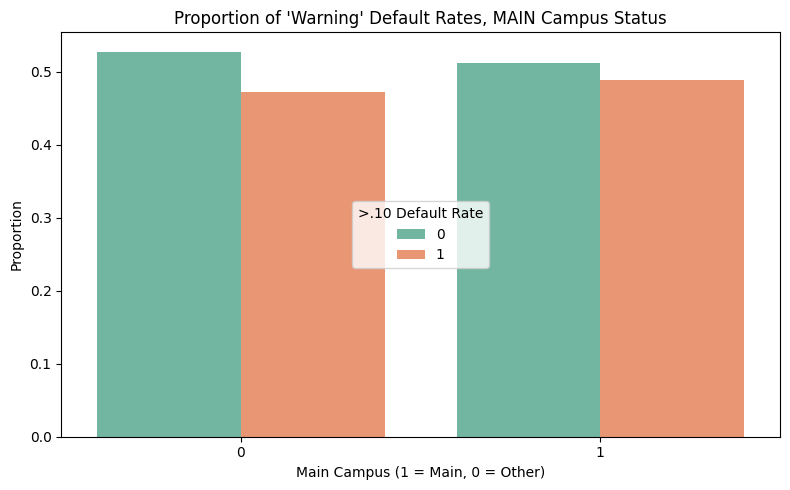

In [50]:
plt.figure(figsize=(8, 5))
main_prop = (
    filtered_df.groupby("MAIN")["valid_category"]
    .value_counts(normalize=True)
    .rename("Proportion")
    .reset_index()
)
sns.barplot(
    data=main_prop,
    x="MAIN",
    y="Proportion",
    hue="valid_category",
    palette="Set2"
)
plt.title("Proportion of 'Warning' Default Rates, MAIN Campus Status")
plt.xlabel("Main Campus (1 = Main, 0 = Other)")
plt.ylabel("Proportion")
plt.legend(title=">.10 Default Rate", loc='center')
plt.tight_layout()
plt.show()

## 6.4 Major Categories

Major category visualizations provide a business-facing way to explain the model.

The goal is not to claim that a field of study causes default. The goal is to identify program categories where observed high-default-risk shares are higher and may deserve closer advising, financial counseling, or program-level review.


Several categories show elevated high-default-risk shares, including Vocational & Technical and Engineering & Technology.

The Engineering & Technology result is somewhat counterintuitive and should be discussed carefully. It may reflect the specific mix of programs and credential levels in the dataset rather than a simple field-level effect.


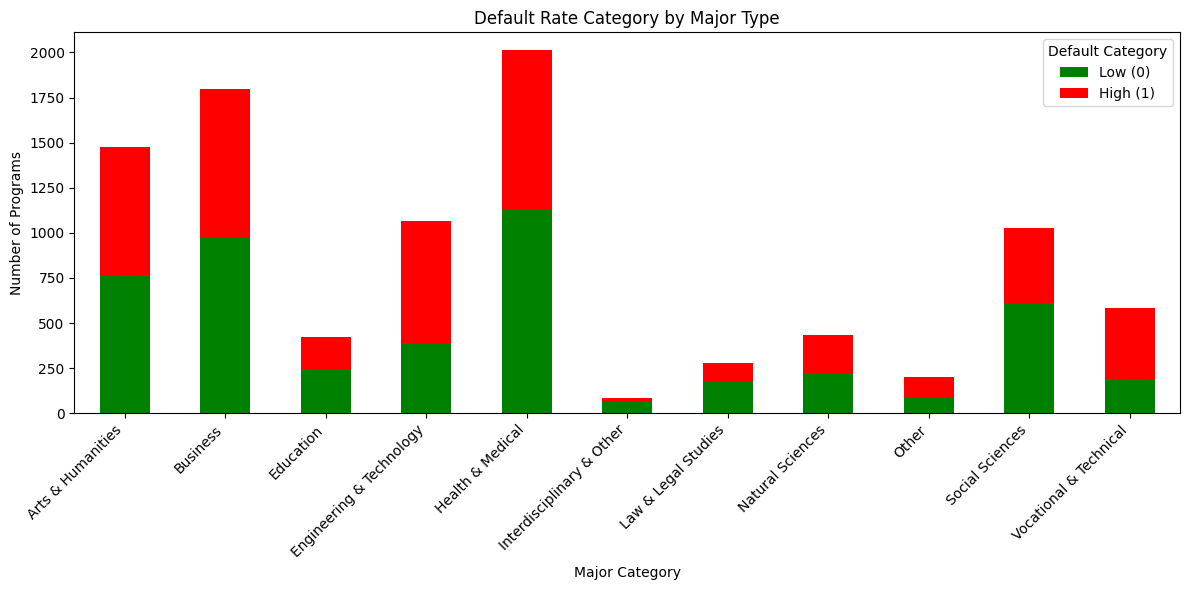

In [51]:
major_cols = [col for col in filtered_df.columns if col.startswith("CIPDESC_Category_")]

melted = filtered_df[major_cols + ['valid_category']].melt(id_vars='valid_category',
                        var_name='Major Category', value_name='Has Major')

melted = melted[melted['Has Major'] == 1]
melted["Major Category"] = melted["Major Category"].str.replace("CIPDESC_Category_", "", regex=False)

counts = melted.groupby(['Major Category', 'valid_category']).size().unstack(fill_value=0)

counts.plot(kind='bar', stacked=True, figsize=(12, 6), color={0: 'green', 1: 'red'})
plt.title("Default Rate Category by Major Type")
plt.ylabel("Number of Programs")
plt.xlabel("Major Category")
plt.legend(title='Default Category', labels=['Low (0)', 'High (1)'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 6.5 Institution Control

Institution control is included as a public/private indicator.

This visual compares high-default-risk classification across public and private institutions.


Private institutions show a higher share of high-default-risk programs than public institutions in this dataset.

This aligns with the model’s use of `CONTROL`, but it should be interpreted as an institutional-level risk signal rather than a causal claim about institution ownership.


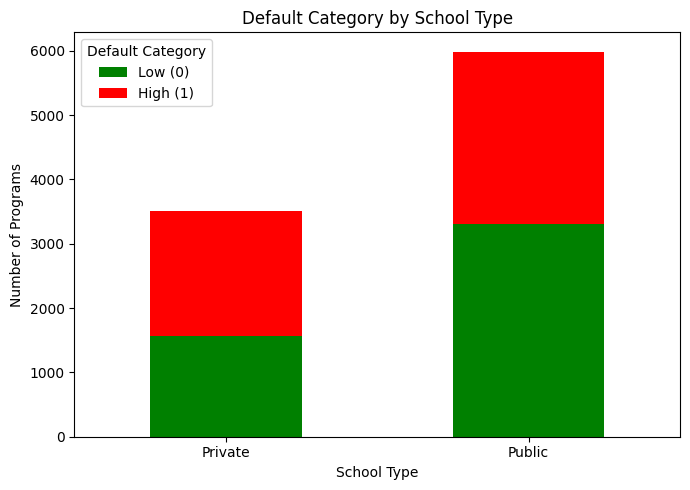

In [52]:
temp_df = filtered_df.copy()
temp_df['School Type'] = temp_df['CONTROL'].map({1: 'Public', 0: 'Private'})

control_counts = temp_df.groupby(['School Type', 'valid_category']).size().unstack(fill_value=0)

control_counts.plot(kind='bar', stacked=True, figsize=(7, 5), color={0: 'green', 1: 'red'})
plt.title("Default Category by School Type")
plt.ylabel("Number of Programs")
plt.xlabel("School Type")
plt.legend(title='Default Category', labels=['Low (0)', 'High (1)'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
temp_control = filtered_df['CONTROL'].map({1: 'Public', 0: 'Private'})
control_table = pd.crosstab(temp_control, filtered_df['valid_category'])

control_table['Total'] = control_table.sum(axis=1)
control_table['Proportion 0'] = (control_table[0] / control_table['Total']).round(3)
control_table['Proportion 1'] = (control_table[1] / control_table['Total']).round(3)

control_table = control_table[[0, 1, 'Total', 'Proportion 0', 'Proportion 1']]
display(control_table)

valid_category,0,1,Total,Proportion 0,Proportion 1
CONTROL,,,,,
Private,1574,1934,3508,0.449,0.551
Public,3311,2678,5989,0.553,0.447


# 7. Deployment and Responsible Use

This model should be treated as a program-level risk-screening tool, not as a decision system for individual students.

Potential uses:

- identify programs that may need stronger financial counseling
- support institutional review of program-level student outcomes
- help students compare financial-risk patterns across program types
- guide dashboard development using College Scorecard data
- support early policy or advising discussions

Important limitation:

> The data is at the program level, not the borrower level. The model should not be used to make assumptions about individual borrowers.

A deployment version would need clear documentation, periodic refreshes with newer College Scorecard data, and careful communication to avoid steering students unfairly based on broad group-level patterns.

In [54]:
import plotly.express as px
import pandas as pd

# Build regional importance values from the Random Forest feature-importance output.
# New England is the reference region because region dummies were created with drop_first=True.
region_importance_values = (
    feature_importance_df[feature_importance_df["Feature"].str.startswith("REGION_")]
    .assign(Region=lambda df: df["Feature"].str.replace("REGION_", "", regex=False))
    .set_index("Region")["Importance"]
    .to_dict()
)

region_importance_values["New England"] = 0.0

# State-to-region mapping based on College Scorecard region definitions
state_region_map = {
    # New England
    'CT': 'New England', 'ME': 'New England', 'MA': 'New England',
    'NH': 'New England', 'RI': 'New England', 'VT': 'New England',

    # Mid East
    'DE': 'Mid East', 'DC': 'Mid East', 'MD': 'Mid East',
    'NJ': 'Mid East', 'NY': 'Mid East', 'PA': 'Mid East',

    # Great Lakes
    'IL': 'Great Lakes', 'IN': 'Great Lakes', 'MI': 'Great Lakes',
    'OH': 'Great Lakes', 'WI': 'Great Lakes',

    # Plains
    'IA': 'Plains', 'KS': 'Plains', 'MN': 'Plains', 'MO': 'Plains',
    'NE': 'Plains', 'ND': 'Plains', 'SD': 'Plains',

    # Southeast
    'AL': 'Southeast', 'AR': 'Southeast', 'FL': 'Southeast',
    'GA': 'Southeast', 'KY': 'Southeast', 'LA': 'Southeast',
    'MS': 'Southeast', 'NC': 'Southeast', 'SC': 'Southeast',
    'TN': 'Southeast', 'VA': 'Southeast', 'WV': 'Southeast',

    # Southwest
    'AZ': 'Southwest', 'NM': 'Southwest', 'OK': 'Southwest', 'TX': 'Southwest',

    # Rocky Mountains
    'CO': 'Rocky Mountains', 'ID': 'Rocky Mountains', 'MT': 'Rocky Mountains',
    'UT': 'Rocky Mountains', 'WY': 'Rocky Mountains',

    # Far West
    'AK': 'Far West', 'CA': 'Far West', 'HI': 'Far West',
    'NV': 'Far West', 'OR': 'Far West', 'WA': 'Far West'
}

# Create DataFrame
state_data = pd.DataFrame({'State': list(state_region_map.keys())})
state_data['Region'] = state_data['State'].map(state_region_map)
state_data['Importance'] = state_data['Region'].map(region_importance_values)

# Plot
fig = px.choropleth(
    state_data,
    locations='State',
    locationmode='USA-states',
    color='Importance',
    scope='usa',
    color_continuous_scale='Reds',
    title='Random Forest Feature Importance by U.S. Region',
)
fig.update_layout(geo=dict(bgcolor='rgba(0,0,0,0)'), plot_bgcolor='white')
fig.show()


# 8. Conclusion

Student loan default risk is a program-level and institution-level problem with consequences for students, schools, lenders, and policymakers. Using College Scorecard field-of-study and institution-level data, this analysis shows that elevated default risk is not randomly distributed across higher education programs.

The strongest and most consistent signal is credential level. Undergraduate Certificate or Diploma programs show substantially higher default-risk patterns, while Bachelor's Degree programs show lower risk. Institution control, distance education status, campus status, region, and major category also provide useful signal for identifying programs more likely to exceed the 10% default-risk threshold.

The modeling results support the central purpose of the project: using data mining to make a large, difficult-to-interpret public dataset more actionable. Logistic Regression provides interpretable coefficients and statistical evidence through p-values, while Random Forest captures nonlinear patterns and supports feature-importance analysis. Together, these models help identify which program and institution characteristics are most associated with default risk.

These findings are most useful as an early risk-screening and decision-support tool. Students could use this type of analysis to compare the financial-risk profile of different program types, while institutions could use it to identify programs that may need stronger advising, financial counseling, or outcome monitoring. Policymakers and lenders could also use program-level risk patterns to supplement broader institution-level default measures.

The results should not be used to make assumptions about individual borrowers. The data is aggregated at the program level, and variables such as credential type, region, institution type, and major category may reflect broader structural differences rather than individual student behavior. Any deployment should include clear documentation, responsible-use guidance, and regular updates as new College Scorecard data becomes available.

A stronger production version would incorporate additional years of data, clearer handling of privacy-suppressed values, program-size weighting, separate treatment of private nonprofit and private for-profit institutions, and fairness review before deployment.

The main takeaway is:

> College Scorecard data can support early identification of higher-risk educational programs, but the results should be used to guide responsible review, advising, and institutional improvement rather than automatic decisions.
